# Human Development Index (HDI) Predictor
### A Comprehensive Measure of Well-Being

This notebook walks through the complete machine learning workflow for predicting the Human Development Index (HDI) score of a country, based on:
- Life Expectancy
- Mean Years of Schooling
- Expected Years of Schooling
- GNI (Gross National Income) Per Capita

**Workflow:**
1. Environment Setup & Library Imports
2. Dataset Loading & Understanding
3. Data Visualization & Exploratory Analysis
4. Data Preprocessing & Feature Engineering
5. Train/Test Split
6. Model Building (Linear Regression)
7. Model Evaluation
8. Model Saving (Pickle Serialization)


## 1. Importing Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Dataset Loading & Understanding

The dataset (`HDI.csv`) contains country-level indicators used to compute the Human Development Index:

| Column | Description |
|---|---|
| Country | Name of the country |
| Life_Expectancy | Average life expectancy at birth (years) |
| Mean_Years_Schooling | Average years of schooling for adults 25+ |
| Expected_Years_Schooling | Expected years of schooling for a child entering school |
| GNI_Per_Capita | Gross National Income per capita (PPP $) |
| HDI_Score | Human Development Index score (0 to 1) — **target variable** |
| HDI_Category | Development tier: Very High / High / Medium / Low |


In [3]:
df = pd.read_csv("../Dataset/HDI.csv")
df.head()

,Country,Life_Expectancy,Mean_Years_Schooling,Expected_Years_Schooling,GNI_Per_Capita,HDI_Score,HDI_Category
0,Norway,78.7,14.3,17.6,66906.0,0.950,Very High
1,Switzerland,76.6,11.5,15.2,85632.0,0.889,Very High
2,Ireland,81.0,13.5,15.1,92893.0,0.934,Very High
3,Germany,83.3,11.7,15.6,37838.0,0.896,Very High
4,Iceland,78.0,12.8,16.5,45386.0,0.900,Very High


In [4]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (167, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   167 non-null    object 
 1   Life_Expectancy           163 non-null    float64
 2   Mean_Years_Schooling      163 non-null    float64
 3   Expected_Years_Schooling  167 non-null    float64
 4   GNI_Per_Capita            163 non-null    float64
 5   HDI_Score                 167 non-null    float64
 6   HDI_Category              167 non-null    object 
dtypes: float64(5), object(2)
memory usage: 9.3+ KB


In [5]:
df.describe()

,Life_Expectancy,Mean_Years_Schooling,Expected_Years_Schooling,GNI_Per_Capita,HDI_Score
count,163.000000,163.000000,167.000000,163.000000,167.000000
mean,70.531902,8.817791,13.404192,22553.478528,0.718970
std,8.504013,3.112915,2.879913,24764.860885,0.162787
min,50.200000,2.300000,7.100000,681.000000,0.361000
25%,65.300000,6.800000,11.450000,5581.500000,0.615500
50%,72.500000,8.900000,13.800000,12898.000000,0.757000
75%,76.200000,11.150000,15.350000,25538.500000,0.865500
max,84.600000,14.300000,18.400000,93024.000000,0.965000


In [6]:
df["HDI_Category"].value_counts()

HDI_Category
High         58
Medium       44
Very High    43
Low          22
Name: count, dtype: int64

## 3. Data Visualization & Exploratory Analysis

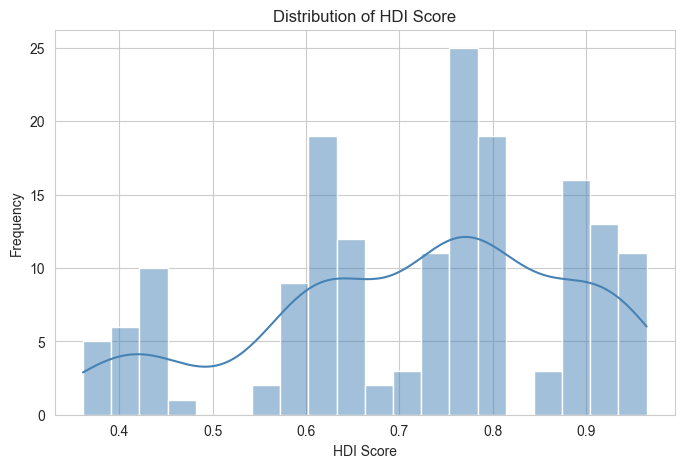

In [7]:
# Distribution of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df["HDI_Score"], bins=20, kde=True, color="steelblue")
plt.title("Distribution of HDI Score")
plt.xlabel("HDI Score")
plt.ylabel("Frequency")
plt.show()

C:\Users\Charan\AppData\Local\Temp\ipykernel_10004\3060961313.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="HDI_Category", y="HDI_Score",


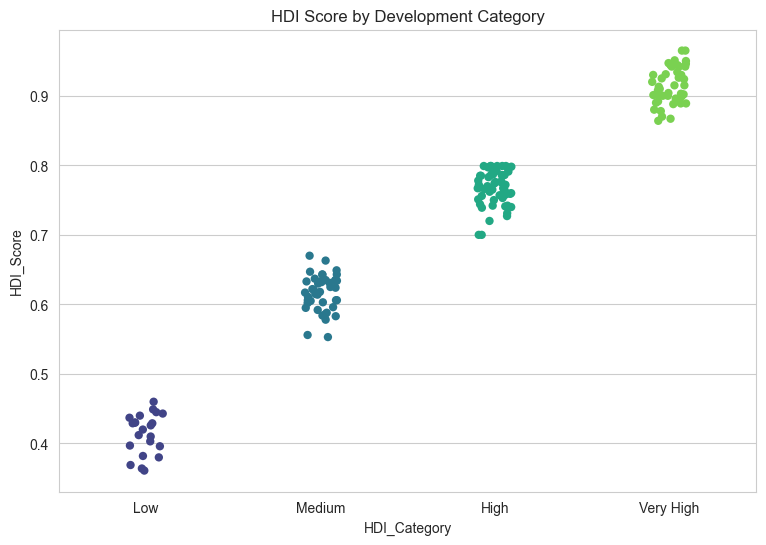

In [8]:
# Strip plot: HDI Score by Category
plt.figure(figsize=(9, 6))
sns.stripplot(data=df, x="HDI_Category", y="HDI_Score",
              order=["Low", "Medium", "High", "Very High"],
              palette="viridis", size=6, jitter=True)
plt.title("HDI Score by Development Category")
plt.show()

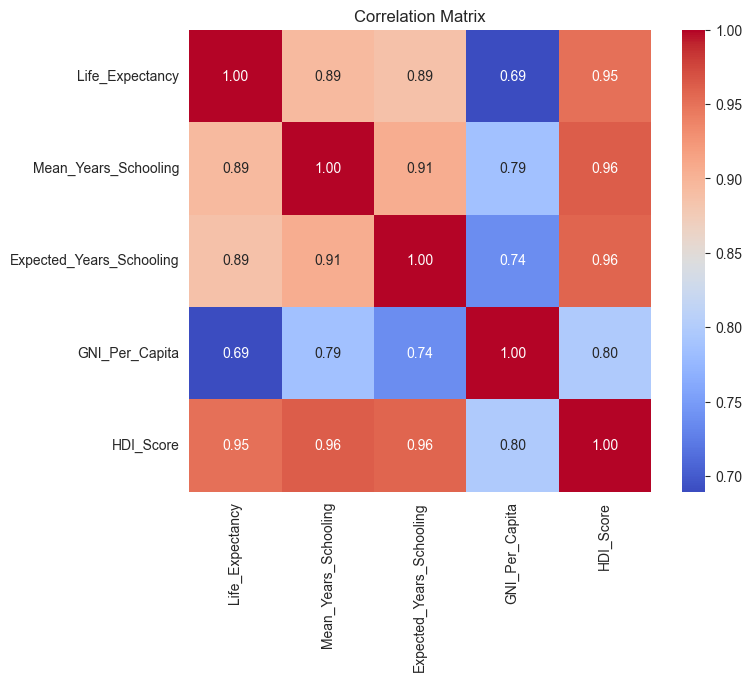

In [9]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
numeric_cols = ["Life_Expectancy", "Mean_Years_Schooling",
                 "Expected_Years_Schooling", "GNI_Per_Capita", "HDI_Score"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()

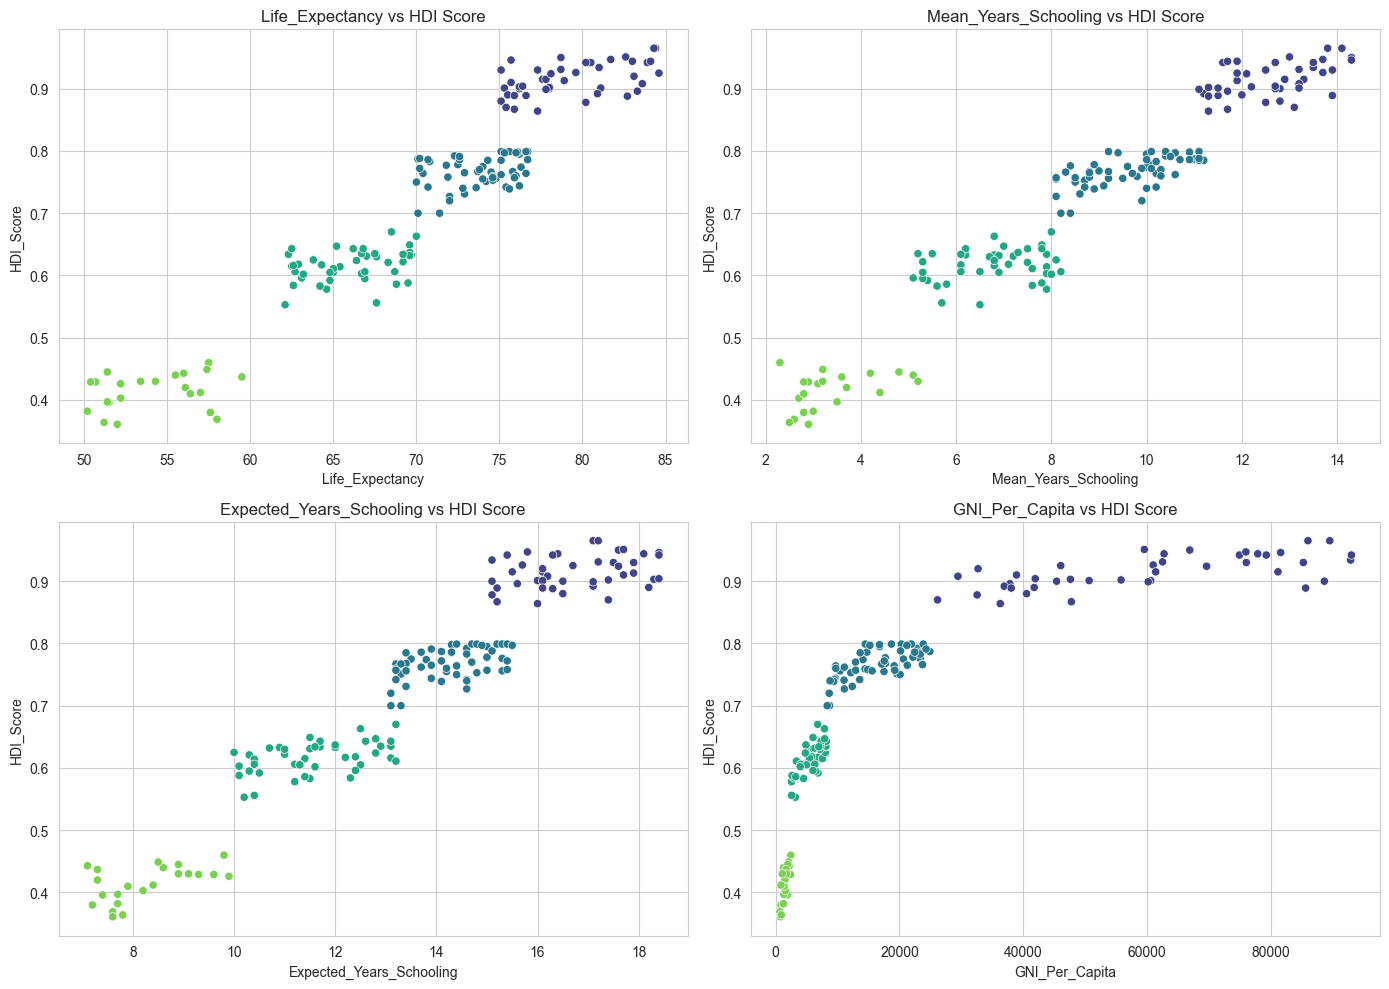

In [10]:
# Scatter plots: each feature vs HDI Score
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ["Life_Expectancy", "Mean_Years_Schooling", "Expected_Years_Schooling", "GNI_Per_Capita"]
for ax, feat in zip(axes.flatten(), features):
    sns.scatterplot(data=df, x=feat, y="HDI_Score", hue="HDI_Category",
                     palette="viridis", ax=ax, legend=False)
    ax.set_title(f"{feat} vs HDI Score")
plt.tight_layout()
plt.show()

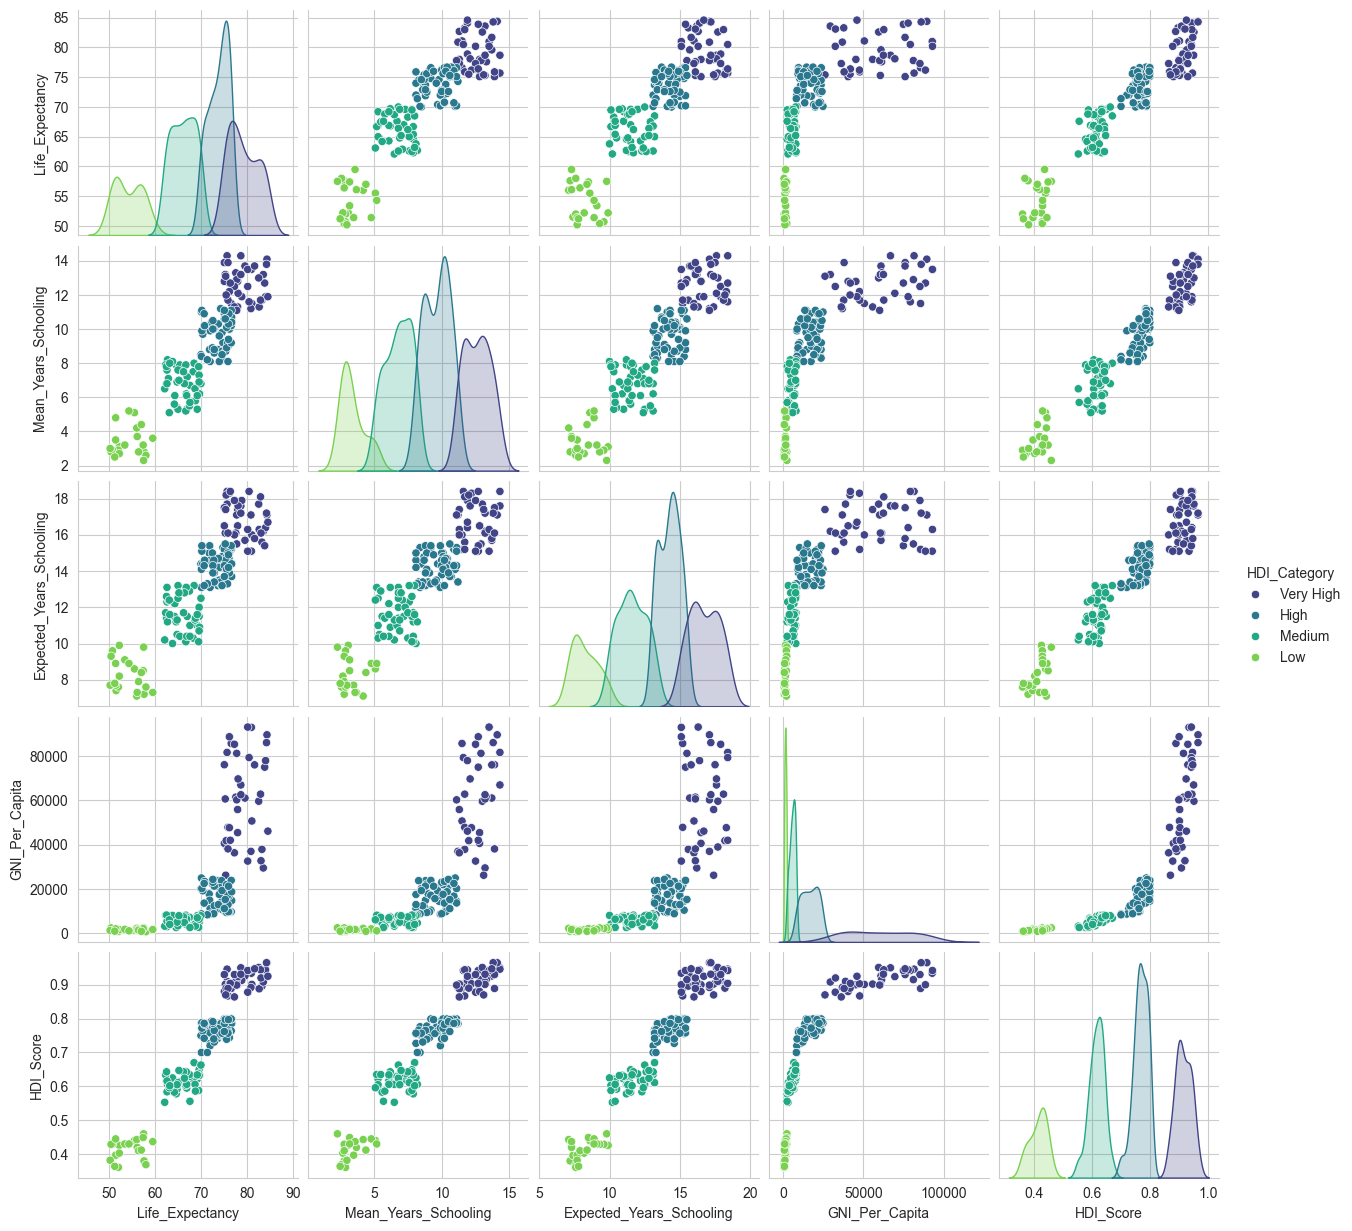

In [11]:
# Pairplot for overall relationships
sns.pairplot(df[numeric_cols + ["HDI_Category"]], hue="HDI_Category", palette="viridis")
plt.show()

## 4. Data Preprocessing & Feature Engineering

Steps:
1. Check for missing values
2. Fill missing numeric values using the column mean
3. Label-encode the categorical `HDI_Category` column (kept as a reference; not used as a model feature since it's derived from the target)
4. Select dependent (target) and independent (features) variables


In [12]:
# Check missing values
df.isnull().sum()

Country                     0
Life_Expectancy             4
Mean_Years_Schooling        4
Expected_Years_Schooling    0
GNI_Per_Capita              4
HDI_Score                   0
HDI_Category                0
dtype: int64

In [13]:
# Fill missing numeric values with column mean
numeric_features = ["Life_Expectancy", "Mean_Years_Schooling", "Expected_Years_Schooling", "GNI_Per_Capita"]
for col in numeric_features:
    df[col] = df[col].fillna(df[col].mean())

df.isnull().sum()

Country                     0
Life_Expectancy             0
Mean_Years_Schooling        0
Expected_Years_Schooling    0
GNI_Per_Capita              0
HDI_Score                   0
HDI_Category                0
dtype: int64

In [14]:
# Label Encoding for HDI_Category (kept for reference/EDA, not used as a regression feature)
le = LabelEncoder()
df["HDI_Category_Encoded"] = le.fit_transform(df["HDI_Category"])
df[["HDI_Category", "HDI_Category_Encoded"]].drop_duplicates().sort_values("HDI_Category_Encoded")

,HDI_Category,HDI_Category_Encoded
43,High,0
145,Low,1
101,Medium,2
0,Very High,3


In [15]:
# Select independent (X) and dependent (y) variables
X = df[["Life_Expectancy", "Mean_Years_Schooling", "Expected_Years_Schooling", "GNI_Per_Capita"]]
y = df["HDI_Score"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Features shape: (167, 4)
Target shape: (167,)


,Life_Expectancy,Mean_Years_Schooling,Expected_Years_Schooling,GNI_Per_Capita
0,78.7,14.3,17.6,66906.0
1,76.6,11.5,15.2,85632.0
2,81.0,13.5,15.1,92893.0
3,83.3,11.7,15.6,37838.0
4,78.0,12.8,16.5,45386.0


## 5. Splitting the Dataset into Train and Test Sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (133, 4)
Testing set size: (34, 4)


## 6. Model Building — Linear Regression

We train a Linear Regression model to predict the continuous HDI score from the four input indicators.


In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)

Model coefficients: [6.02575700e-03 1.44882694e-02 2.05662510e-02 6.86765059e-07]
Model intercept: -0.1250266645365441


In [18]:
# Generate predictions on test set
y_pred = model.predict(X_test)

results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.round(y_pred, 3)
})
results_df.head(10)

,Actual,Predicted
0,0.578,0.611
1,0.595,0.571
2,0.788,0.783
3,0.758,0.763
4,0.791,0.767
5,0.944,0.960
6,0.621,0.611
7,0.765,0.742
8,0.617,0.606
9,0.584,0.617


### Model Evaluation

In [19]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-Squared Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.0166
Mean Squared Error (MSE): 0.0005
Root Mean Squared Error (RMSE): 0.0225
R-Squared Score: 0.9800


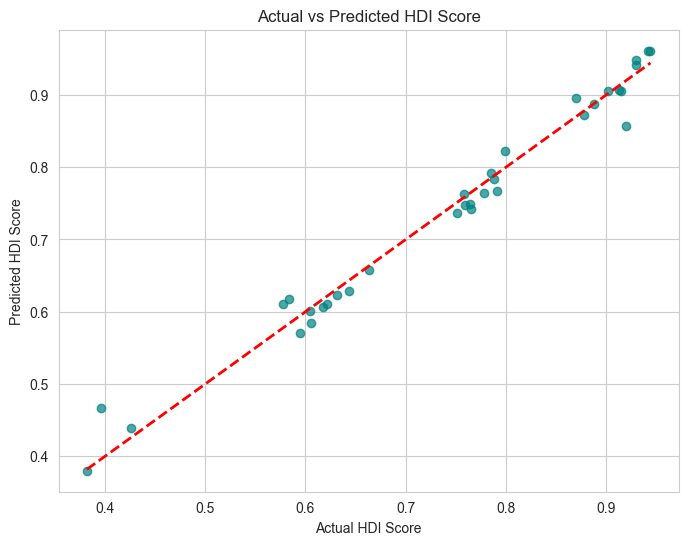

In [20]:
# Visualize Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual HDI Score")
plt.ylabel("Predicted HDI Score")
plt.title("Actual vs Predicted HDI Score")
plt.show()

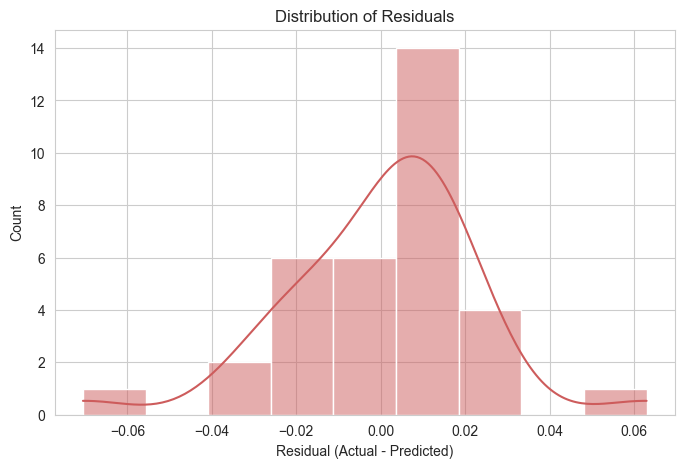

In [21]:
# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color="indianred")
plt.title("Distribution of Residuals")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()

C:\Users\Charan\AppData\Local\Temp\ipykernel_10004\503674050.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="viridis")


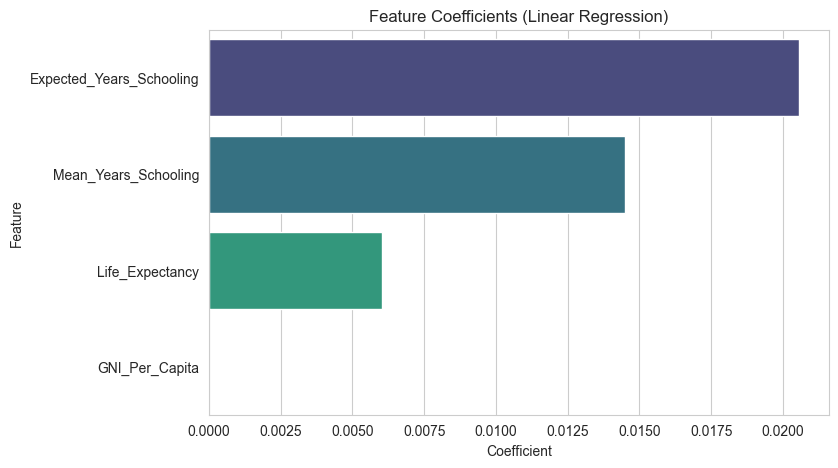

,Feature,Coefficient
2,Expected_Years_Schooling,2.056625e-02
1,Mean_Years_Schooling,1.448827e-02
0,Life_Expectancy,6.025757e-03
3,GNI_Per_Capita,6.867651e-07


In [22]:
# Feature importance via coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="viridis")
plt.title("Feature Coefficients (Linear Regression)")
plt.show()
coef_df

## 7. Saving the Trained Model

The trained model is serialized using `pickle` so that it can be loaded directly inside the Flask web application without retraining.


In [23]:
model_path = "../Flask/HDI.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)

print(f"Model saved successfully to {model_path}")

Model saved successfully to ../Flask/HDI.pkl


In [24]:
# Quick sanity check: reload the model and test a prediction
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

sample_input = pd.DataFrame([{
    "Life_Expectancy": 78.5,
    "Mean_Years_Schooling": 11.5,
    "Expected_Years_Schooling": 15.8,
    "GNI_Per_Capita": 42000
}])

sample_pred = loaded_model.predict(sample_input)
print("Sample predicted HDI score:", round(sample_pred[0], 3))

Sample predicted HDI score: 0.868


## 8. Conclusion

The Linear Regression model was trained on country-level life expectancy, education, and income indicators to predict the Human Development Index score. The model achieved a strong fit (see R-Squared above) and has been saved as `HDI.pkl` for use in the Flask web application, where users can input country indicators and receive a predicted HDI score along with its development tier classification.
